# **Step 1:Cleaning (Redundant Columns, Duplicates, Attrition Conversion, Label Encoding)**


## Load and check on data

In [54]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("HR-Employee-Attrition.csv")

In [55]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [57]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [58]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [59]:
df_processed = df.copy()

##Deleting redundant columns

In [60]:
columns_to_drop = ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]
df_processed = df_processed.drop(columns=columns_to_drop, errors="ignore")
print(f"Dropped redundant columns: {columns_to_drop}")

Dropped redundant columns: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']


## Dropping duplicates



In [61]:
initial_rows = df_processed.shape[0]
df_processed.drop_duplicates(inplace=True)
if df_processed.shape[0] < initial_rows:
    print(f"Dropped {initial_rows - df_processed.shape[0]} duplicate rows.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


## Convert "Attrition" to numerical (Yes=1, No=0)

In [62]:
df_processed["Attrition"] = df_processed["Attrition"].map({"Yes": 1, "No": 0})
print("Converted 'Attrition' to numerical values: Yes=1, No=0")

Converted 'Attrition' to numerical values: Yes=1, No=0


## Apply Label Encoding to other categorical columns

In [63]:
categorical_cols = df_processed.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
print(f"Applied Label Encoding to categorical columns: {list(categorical_cols)}")

print("\n")

print("Data after initial cleaning and encoding:")
print(df_processed.info())

df_after_cleaning = df_processed.copy()


Applied Label Encoding to categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


Data after initial cleaning and encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   int64
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   int64
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   int64
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   int64
 10  HourlyRate                1470 non-null   int64
 11  JobInvo

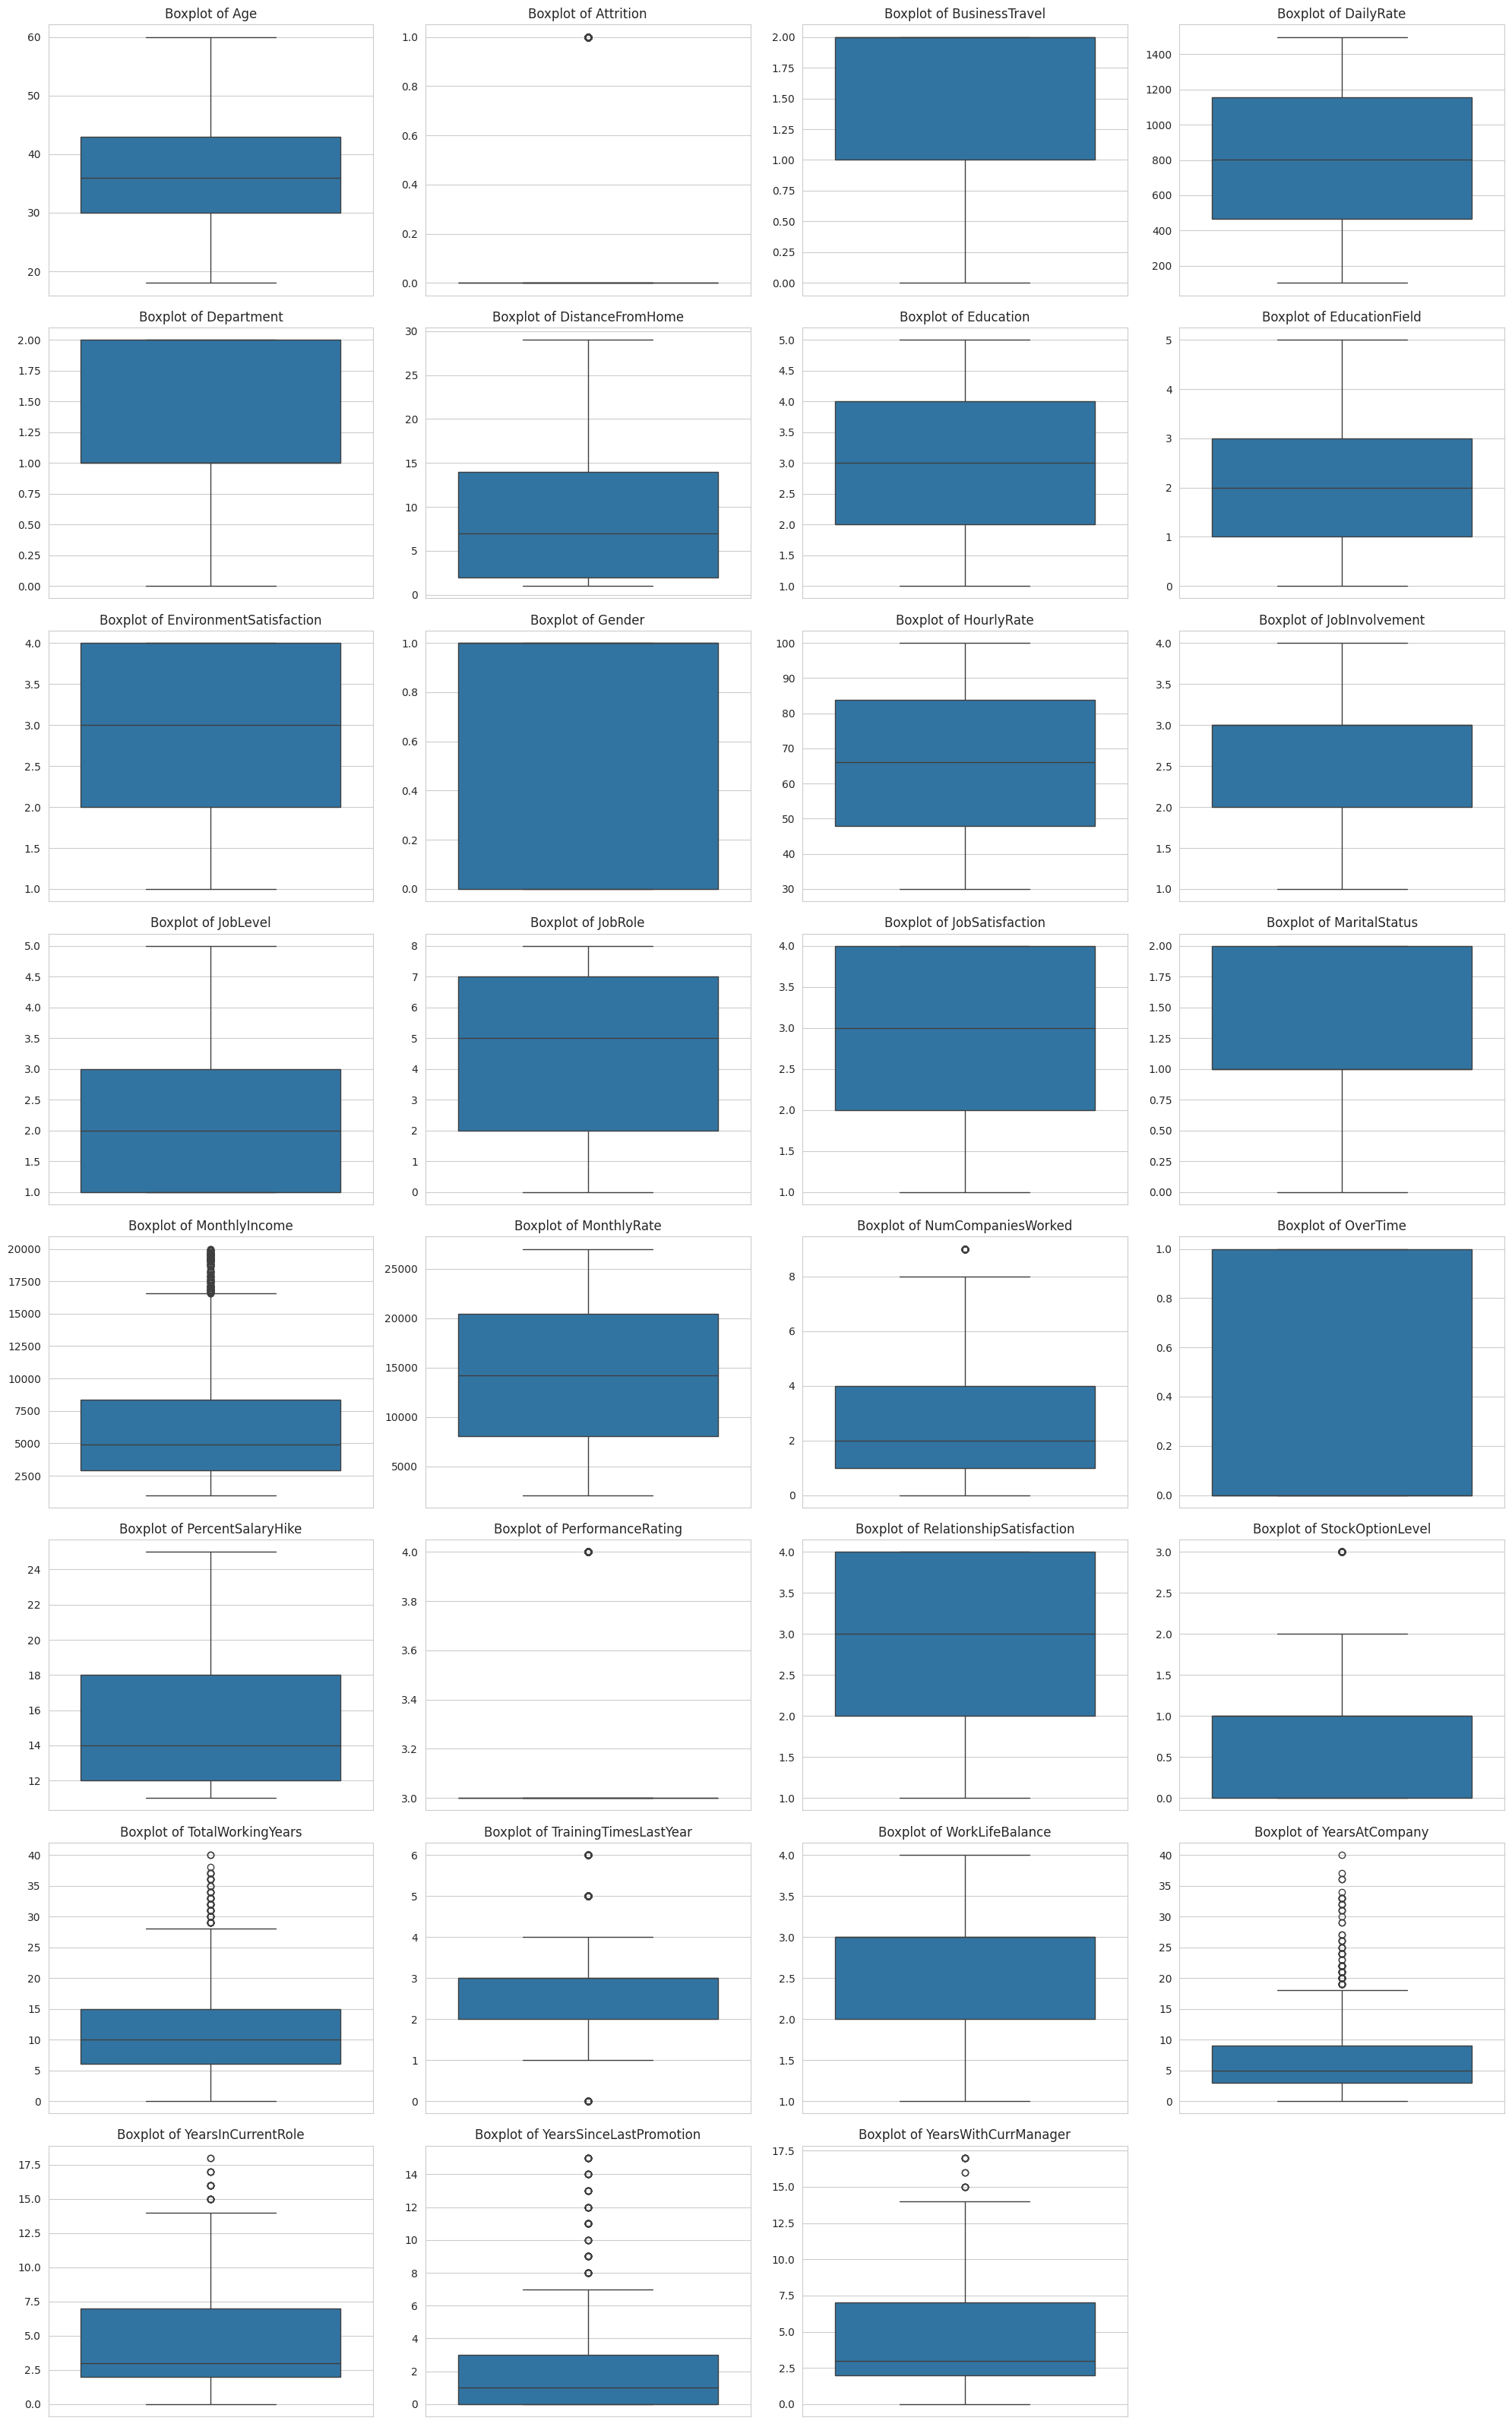

In [64]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

columns = df_after_cleaning.columns

n_cols = 4
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))

axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(y=df_after_cleaning[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [65]:
df_processed.shape

(1470, 31)

## Define features (X) and target (y)


In [66]:
X = df_processed.drop("Attrition", axis=1)
y = df_processed["Attrition"]

## Remove (Attrition') from numerical_cols , as it's now the target variable


In [67]:
numerical_cols = df_processed.select_dtypes(exclude=['object']).columns.tolist()
numerical_cols.remove('Attrition')

## Split the data into training and testing sets

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [69]:
df_processed.shape

(1470, 31)

## 4. Perform feature scaling (StandardScaler)


In [70]:
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [71]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# **Step 2: Implementation of models**

## Load preprocessed data


In [72]:
%pip install catboost

In [73]:
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, silhouette_score

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

In [74]:
results = {}

def evaluate_classification_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")


## 1. Linear Regression

In [75]:
print("\n--- Linear Regression ---")
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin_reg = (lin_reg.predict(X_test) > 0.5).astype(int)
accuracy_lin_reg = accuracy_score(y_test, y_pred_lin_reg)
precision_lin_reg = precision_score(y_test, y_pred_lin_reg, zero_division=0)
recall_lin_reg = recall_score(y_test, y_pred_lin_reg, zero_division=0)
f1_lin_reg = f1_score(y_test, y_pred_lin_reg, zero_division=0)

results["Linear Regression"] = {
    "Accuracy": accuracy_lin_reg,
    "Precision": precision_lin_reg,
    "Recall": recall_lin_reg,
    "F1-Score": f1_lin_reg
}
print(f"Linear Regression - Accuracy: {accuracy_lin_reg:.4f}, Precision: {precision_lin_reg:.4f}, Recall: {recall_lin_reg:.4f}, F1-Score: {f1_lin_reg:.4f}")


--- Linear Regression ---
Linear Regression - Accuracy: 0.8776, Precision: 1.0000, Recall: 0.2340, F1-Score: 0.3793


## 2. Logistic Regression


In [76]:
print("\n--- Logistic Regression ---")
evaluate_classification_model(LogisticRegression(max_iter=1000, solver='liblinear'), "Logistic Regression")


--- Logistic Regression ---
Logistic Regression - Accuracy: 0.8741, Precision: 0.6923, Recall: 0.3830, F1-Score: 0.4932


## 3. Decision Trees


In [77]:
print("\n--- Decision Trees ---")
evaluate_classification_model(DecisionTreeClassifier(random_state=42), "Decision Trees")


--- Decision Trees ---
Decision Trees - Accuracy: 0.7823, Precision: 0.3191, Recall: 0.3191, F1-Score: 0.3191


## 4. Random Forest


In [78]:
print("\n--- Random Forest ---")
evaluate_classification_model(RandomForestClassifier(random_state=42), "Random Forest")


--- Random Forest ---
Random Forest - Accuracy: 0.8401, Precision: 0.5000, Recall: 0.1277, F1-Score: 0.2034


## 5. Support Vector Machine (SVM)


In [79]:
print("\n--- Support Vector Machine (SVM) ---")
evaluate_classification_model(SVC(random_state=42), "Support Vector Machine (SVM)")


--- Support Vector Machine (SVM) ---
Support Vector Machine (SVM) - Accuracy: 0.8537, Precision: 0.6667, Recall: 0.1702, F1-Score: 0.2712


## 6. K-Nearest Neighbor (KNN)

In [80]:
print("\n--- K-Nearest Neighbor (KNN) ---")
evaluate_classification_model(KNeighborsClassifier(), "K-Nearest Neighbor (KNN)")


--- K-Nearest Neighbor (KNN) ---
K-Nearest Neighbor (KNN) - Accuracy: 0.8537, Precision: 0.6667, Recall: 0.1702, F1-Score: 0.2712


## 7. Naive Bayes


In [81]:
print("\n--- Naive Bayes ---")
evaluate_classification_model(GaussianNB(), "Naive Bayes")


--- Naive Bayes ---
Naive Bayes - Accuracy: 0.7415, Precision: 0.3441, Recall: 0.6809, F1-Score: 0.4571


## 8. Gradient Boosting


In [82]:
print("\n--- Gradient Boosting (XGBoost) ---")
evaluate_classification_model(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), "XGBoost")

print("\n")

print("\n--- Gradient Boosting (LightGBM) ---")
evaluate_classification_model(LGBMClassifier(random_state=42), "LightGBM")

print("\n")

print("\n--- Gradient Boosting (CatBoost) ---")
evaluate_classification_model(CatBoostClassifier(random_state=42, verbose=0), "CatBoost")


--- Gradient Boosting (XGBoost) ---


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [18:06:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost - Accuracy: 0.8469, Precision: 0.5556, Recall: 0.2128, F1-Score: 0.3077



--- Gradient Boosting (LightGBM) ---
[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1149
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632
LightGBM - Accuracy: 0.8537, Precision: 0.6111, Recall: 0.2340, F1-Score: 0.3385



--- Gradient Boosting (CatBoost) ---
CatBoost - Accuracy: 0.8605, Precision: 0.7500, Recall: 0.1915, F1-Score: 0.3051



# **Step 3: Models summary**

In [83]:
import pandas as pd

results_df = pd.DataFrame(results).T

results_df = results_df.round(4)

print("\n--- Model Performance Summary ---")
print(results_df)

best_model_name = results_df["Accuracy"].idxmax()
best_model_score = results_df.loc[best_model_name, "Accuracy"]

print(f"\n\n Best Model: {best_model_name} with Accuracy = {best_model_score:.4f}")



--- Model Performance Summary ---
                              Accuracy  Precision  Recall  F1-Score
Linear Regression               0.8776     1.0000  0.2340    0.3793
Logistic Regression             0.8741     0.6923  0.3830    0.4932
Decision Trees                  0.7823     0.3191  0.3191    0.3191
Random Forest                   0.8401     0.5000  0.1277    0.2034
Support Vector Machine (SVM)    0.8537     0.6667  0.1702    0.2712
K-Nearest Neighbor (KNN)        0.8537     0.6667  0.1702    0.2712
Naive Bayes                     0.7415     0.3441  0.6809    0.4571
XGBoost                         0.8469     0.5556  0.2128    0.3077
LightGBM                        0.8537     0.6111  0.2340    0.3385
CatBoost                        0.8605     0.7500  0.1915    0.3051


 Best Model: Linear Regression with Accuracy = 0.8776


In [84]:
from IPython.display import display
display(results_df)

,Accuracy,Precision,Recall,F1-Score
Linear Regression,0.8776,1.0000,0.2340,0.3793
Logistic Regression,0.8741,0.6923,0.3830,0.4932
Decision Trees,0.7823,0.3191,0.3191,0.3191
Random Forest,0.8401,0.5000,0.1277,0.2034
Support Vector Machine (SVM),0.8537,0.6667,0.1702,0.2712
K-Nearest Neighbor (KNN),0.8537,0.6667,0.1702,0.2712
Naive Bayes,0.7415,0.3441,0.6809,0.4571
XGBoost,0.8469,0.5556,0.2128,0.3077
LightGBM,0.8537,0.6111,0.2340,0.3385
CatBoost,0.8605,0.7500,0.1915,0.3051
